# scikit-ops basics

Start here.

An **op** is an ordinary Python function. `otsu` thresholds an image; you can
call it the way you would call anything else, and it runs right here in this
kernel.

The same function can also be run in an environment of its own -- a separate
process with its own installed packages, which skop builds for it. Nothing
about the function changes between the two; only who executes it does. That
is the whole idea, and this notebook shows both calls on one small image.

For thresholding, the second form buys you nothing -- scikit-image is already
here. It earns its keep when the op needs CUDA, or a five-year-old numpy, or
a deep learning stack you would rather not install next to everything else.

## What you need

Three packages: **scikit-ops**, **matplotlib** to draw with, and
**scikit-image** for the sample image and for the op below to run against
directly. Pick whichever of these you already use — they all end up in the
same place.

**pip**

```sh
pip install scikit-ops matplotlib scikit-image
```

> *scikit-ops is not on PyPI quite yet — coming soon. Until then, from a
> clone of the repository: `pip install -e .`*

**uv** — from a clone of the repository:

```sh
uv sync                 # the `examples` group comes by default
uv run jupyter lab      # VS Code: skip this, select .venv as the kernel
```

**pixi** — from a clone of the repository:

```sh
cd pixi/examples
pixi install
pixi run register-kernel   # offers "scikit-ops (examples)" as a kernel
pixi run lab               # VS Code: skip this, select that kernel
```

That really is all, even for the ops that use PyTorch or CUDA: an op's own
environment is built by skop when it is first needed, and nothing of it is
installed alongside your notebook.

Two things to know before that first build:

- it takes a few minutes, once per environment, and the cell will sit there
  looking stuck if nothing is printing progress;
- environments are real installs on disk — small for this one, gigabytes for
  a PyTorch stack.

## An image

`skimage.data.coins()` -- 303 x 384, 8-bit greyscale, and it ships with the
package. Coins on a dark background is about the friendliest thing you can
hand a threshold.

(303, 384) uint8, range 1-252


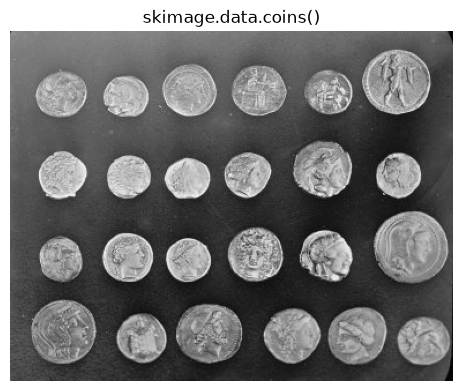

In [4]:
import matplotlib.pyplot as plt
from skimage.data import coins

image = coins()
print(f"{image.shape} {image.dtype}, range {image.min()}-{image.max()}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(image, cmap="gray")
ax.set_title("skimage.data.coins()")
ax.axis("off")
fig.tight_layout()

## 1. Call the op directly

Import it and call it. There is no setup, no session, no wrapper -- this is
the plain function, running in this kernel, and it needs scikit-image to be
installed here because that is what it uses.

`label_objects` is on by default, which gives one number per connected blob.
Turned off it returns a 0/1 mask, which is the clearer thing to look at first.

(303, 384) uint16, values [np.uint16(0), np.uint16(1)]


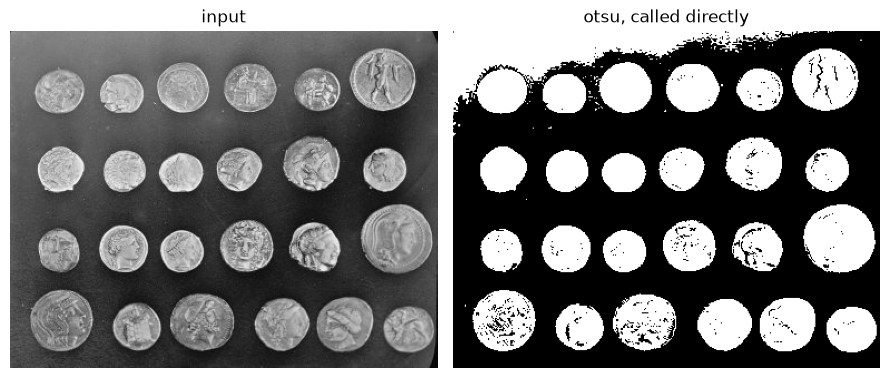

In [5]:
from skop.ops.threshold import otsu

mask = otsu(image, label_objects=False)

print(f"{mask.shape} {mask.dtype}, values {sorted(set(mask.flat))}")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("input")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("otsu, called directly")
for ax in axes:
    ax.axis("off")
fig.tight_layout()

## 2. Run the same op in its own environment

A `Runner` builds the environment an op declares, starts a worker process in
it, and passes the arrays back and forth through shared memory. The op is
handed to `run` as a value -- the same `otsu` object imported above -- and its
arguments are given by name.

Here this is pure ceremony: `otsu` asks for the `skimage` environment, and
scikit-image is already installed in this kernel, so the answer is identical
and slower to get. The point is that the call looks exactly like this for
`cellpose`, `fastsam` or the CUDA deconvolution too -- ops you could not
import here without dragging their whole stack in with them.

`on_progress` is worth passing from the start. The first run of any op pauses
while its environment is built, and this is what tells you the pause is work
rather than a hang.

A `Runner` keeps its workers warm between calls, so make one and reuse it --
then close it when you are done with it.

same answer as the direct call: True


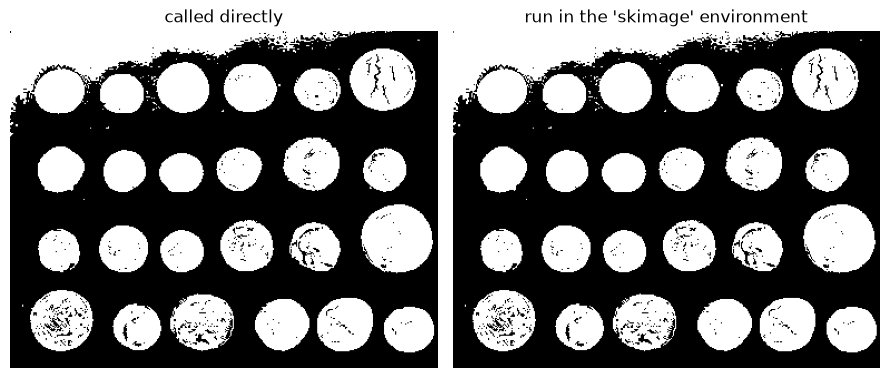

In [6]:
import numpy as np

import skop

runner = skop.Runner()


def show_progress(event):
    if event.message:
        print(event.message)


isolated = runner.run(
    otsu,
    image=image,
    label_objects=False,
    on_progress=show_progress,
)

runner.close()

print(f"same answer as the direct call: {np.array_equal(mask, isolated)}")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(mask, cmap="gray")
axes[0].set_title("called directly")
axes[1].imshow(isolated, cmap="gray")
axes[1].set_title("run in the 'skimage' environment")
for ax in axes:
    ax.axis("off")
fig.tight_layout()

## Which form to use

Call it directly when the op's packages are ones you are happy to have in your
own environment -- most of `skop.ops.threshold`, `smooth`, `morphology` and
`edges` are scikit-image, and importing them costs nothing.

Use a `Runner` when it is not: Cellpose, StarDist, SAM, the cupy
deconvolution, or anything pinned to a Python version you do not want. Also
use one when two ops in the same script disagree about numpy -- that is a
conflict with no solution inside one environment, and none of your business
with two.

To see what else is here:

```python
specs, failures = skop.discover()
```

In [8]:
specs, failures = skop.discover()

print(failures)

for spec in specs:
    print(spec)

[]
OpSpec(name='skop.ops.deconvolve.richardson_lucy:richardson_lucy', module='skop.ops.deconvolve.richardson_lucy', function='richardson_lucy', env='skimage', main_thread=False, exclusive=False, form='function', params=(ParamSpec(name='image', type=<class 'numpy.ndarray'>, default=<class 'inspect._empty'>, direction=None, ui={}, role=None, axes=None, choices=None, params_for=None), ParamSpec(name='psf', type=<class 'numpy.ndarray'>, default=<class 'inspect._empty'>, direction=None, ui={}, role=None, axes=None, choices=None, params_for=None), ParamSpec(name='num_iters', type=<class 'int'>, default=10, direction=None, ui={'min': 1, 'max': 1000}, role=None, axes=None, choices=None, params_for=None), ParamSpec(name='noncirc', type=<class 'bool'>, default=False, direction=None, ui={}, role=None, axes=None, choices=None, params_for=None), ParamSpec(name='mask', type=numpy.ndarray | None, default=None, direction=None, ui={}, role=None, axes=None, choices=None, params_for=None)), return_type=<